In [1]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Датасет

Два признака (x₁, x₂) и два класса:
- **Класс 1** (синий) — точки внутри круга радиуса 2
- **Класс 0** (красный) — точки во внешнем кольце (радиус 3–5)

Линейная граница (прямая) не может разделить эти классы — нужна нелинейная модель.

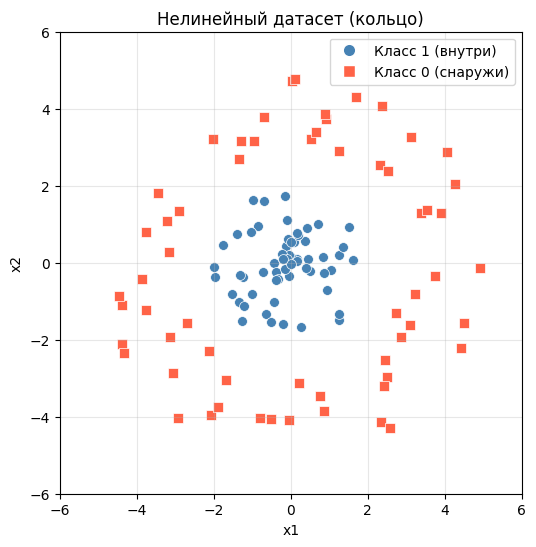

In [2]:
random.seed(42)
n_per_class = 60

data = []

# Класс 1 — внутренний круг (радиус 0..2)
for _ in range(n_per_class):
    r     = random.uniform(0, 2)
    angle = random.uniform(0, 2 * math.pi)
    x1    = r * math.cos(angle)
    x2    = r * math.sin(angle)
    data.append((x1, x2, 1))

# Класс 0 — внешнее кольцо (радиус 3..5)
for _ in range(n_per_class):
    r     = random.uniform(3, 5)
    angle = random.uniform(0, 2 * math.pi)
    x1    = r * math.cos(angle)
    x2    = r * math.sin(angle)
    data.append((x1, x2, 0))

features = [(x1, x2) for x1, x2, _ in data]
labels   = [label for _, _, label in data]

# Визуализация датасета
plt.figure(figsize=(6, 6))
for (x1, x2), label in zip(features, labels):
    color  = 'steelblue' if label == 1 else 'tomato'
    marker = 'o'         if label == 1 else 's'
    plt.scatter(x1, x2, color=color, marker=marker, s=50, edgecolors='white', linewidths=0.5)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=9, label='Класс 1 (внутри)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='tomato',    markersize=9, label='Класс 0 (снаружи)'),
]
plt.legend(handles=legend_elements)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Нелинейный датасет (кольцо)')
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3)
plt.show()

# Визуализация границы решения

`plot_decision_boundary(predict_fn)` принимает функцию `predict_fn(x1, x2) → 0 или 1` и рисует:
- закрашенные зоны — области, которые модель относит к каждому классу
- фиолетовую линию — саму границу решения
- точки — обучающий датасет

In [3]:
def plot_decision_boundary(predict_fn, title='Граница решения'):
    """
    Визуализирует границу решения нейронной сети.

    predict_fn — функция (x1, x2) -> 0 или 1 (или вероятность).
                 Строит сетку точек, вызывает predict_fn для каждой и
                 закрашивает области в цвета классов.
    """
    h = 0.12  # шаг сетки: меньше — точнее, но медленнее

    x1_vals = np.arange(-6, 6 + h, h)
    x2_vals = np.arange(-6, 6 + h, h)
    xx1, xx2 = np.meshgrid(x1_vals, x2_vals)

    # Вызываем predict_fn для каждой точки сетки
    Z = np.array([[predict_fn(x1, x2) for x1 in x1_vals] for x2 in x2_vals])

    plt.figure(figsize=(6, 6))

    # Закрашиваем зоны классов
    plt.contourf(xx1, xx2, Z, alpha=0.35, levels=1, colors=['tomato', 'steelblue'])
    # Граница решения (там где predict_fn = 0.5)
    plt.contour(xx1, xx2, Z, levels=[0.5], colors='purple', linewidths=2)

    # Точки датасета поверх фона
    for (x1, x2), label in zip(features, labels):
        color  = 'steelblue' if label == 1 else 'tomato'
        marker = 'o'         if label == 1 else 's'
        plt.scatter(x1, x2, color=color, marker=marker, s=50,
                    edgecolors='white', linewidths=0.5)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=9, label='Класс 1'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='tomato',    markersize=9, label='Класс 0'),
        Line2D([0], [0], color='purple', linewidth=2, label='Граница решения'),
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.gca().set_aspect('equal')
    plt.grid(True, alpha=0.3)
    plt.show()

# Нейронная сеть (MLP)

Полносвязная нейронная сеть — это несколько слоёв персептронов, соединённых последовательно. Выходы каждого слоя становятся входами следующего. Функции активации между слоями добавляют нелинейность, без которой вся сеть была бы эквивалентна одному линейному слою.

## Архитектура

```
Входной слой     Скрытый слой       Выходной слой
   x1  ──┐
          ├──► [ReLU] нейрон 1 ──┐
   x2  ──┘                        ├──► [Sigmoid] → ŷ ∈ (0, 1)
          ├──► [ReLU] нейрон 2 ──┤
          └──► [ReLU] нейрон 3 ──┘
```

## Forward pass

Прогон данных слева направо — получаем прогноз:

```
z1 = X @ W1 + b1   # линейная часть скрытого слоя
a1 = relu(z1)       # активация
z2 = a1 @ W2 + b2  # линейная часть выходного нейрона
a2 = sigmoid(z2)   # итоговая вероятность класса 1
```

## Backward pass (Backpropagation)

Обновление весов справа налево через цепное правило. Ошибка выходного слоя передаётся в скрытый, взвешенная по весам связей:

```
delta_out = y - a2                              # ошибка выходного слоя
dW2       = delta_out * a1                      # градиент весов выхода

delta1    = delta_out * W2 * relu'(z1)          # ошибка скрытого слоя:
                                                # доля каждого нейрона = его вес W2[j]
                                                # relu'(z1) = 0 для "мёртвых" нейронов
dW1       = outer(X, delta1)                    # градиент весов скрытого слоя
```

## Веса как матрицы

- `W1` shape `(n_inputs, n_hidden)` — столбец = один нейрон скрытого слоя
- `W2` shape `(n_hidden,)` — веса выходного нейрона
- `X @ W1` вычисляет линейную часть всех нейронов скрытого слоя за одну операцию

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)        # поэлементно: отрицательные → 0

def relu_derivative(z):
    return (z > 0).astype(float)   # 1 где нейрон активировался, 0 где нет

def calc_log_loss(y, y_pred):
    return -y * np.log(y_pred) - (1 - y) * np.log(1 - y_pred)

In [5]:
np.random.seed(42)
epochs        = 2000
learning_rate = 0.06

# Архитектура: 2 входа → n_hidden нейронов → 1 выход
n_hidden = 3

# Веса скрытого слоя: матрица (n_inputs, n_hidden)
# Каждый столбец — веса одного нейрона скрытого слоя
# W1[i, j] — вес связи от входа i к нейрону j
W1 = np.random.uniform(-0.5, 0.5, size=(2, n_hidden))
b1 = np.zeros(n_hidden)

# Веса выходного нейрона: вектор (n_hidden,)
# W2[j] — вес связи от нейрона j скрытого слоя к выходу
W2 = np.random.uniform(-0.5, 0.5, size=(n_hidden,))
b2 = 0.0

def get_predict(x1, x2):
    X  = np.array([x1, x2])
    z1 = X @ W1 + b1      # (2,)@(2,n_hidden) → (n_hidden,): линейная часть скрытого слоя
    a1 = relu(z1)          # (n_hidden,): выходы скрытого слоя после активации
    z2 = a1 @ W2 + b2      # (n_hidden,)@(n_hidden,) → scalar: линейная часть выхода
    a2 = sigmoid(z2)       # scalar: вероятность класса 1
    return float(a2)

loss_history = []

for epoch in range(epochs):
    if epoch % 100 == 0:
        total_loss = sum(calc_log_loss(y, get_predict(x1, x2)) for x1, x2, y in data)
        loss_history.append(total_loss)
        print(f"{epoch=} {total_loss=:.2f}")

    # Случайная точка (SGD)
    i          = random.randint(0, len(data) - 1)
    x1, x2, y = data[i]
    X          = np.array([x1, x2])   # (2,)

    # --- Forward pass ---
    z1 = X @ W1 + b1    # (n_hidden,): линейная часть каждого нейрона скрытого слоя
    a1 = relu(z1)        # (n_hidden,): выходы скрытого слоя

    z2 = a1 @ W2 + b2   # scalar: линейная часть выходного нейрона
    a2 = sigmoid(z2)    # scalar: итоговый прогноз

    # --- Backward pass ---
    # Шаг 1: ошибка выходного слоя
    delta_out = y - a2                               # scalar

    # Шаг 2: градиенты весов выходного слоя
    # dW2[j] = delta_out * a1[j]
    # — насколько нейрон j скрытого слоя повлиял на итоговую ошибку
    dW2 = delta_out * a1                             # (n_hidden,)
    db2 = delta_out                                  # scalar

    # Шаг 3: ошибка скрытого слоя
    # Каждый нейрон j получает долю ошибки пропорционально своему весу W2[j]
    # Умножаем на relu_derivative(z1): если нейрон не активировался — градиент не проходит
    delta1 = delta_out * W2 * relu_derivative(z1)   # (n_hidden,)

    # Шаг 4: градиенты весов скрытого слоя
    # dW1[i, j] = X[i] * delta1[j]
    # — вклад входа i в ошибку нейрона j
    dW1 = np.outer(X, delta1)                        # (2, n_hidden)
    db1 = delta1                                     # (n_hidden,)

    # --- Обновление весов (выходной слой → скрытый слой) ---
    W2 += learning_rate * dW2
    b2 += learning_rate * db2
    W1 += learning_rate * dW1
    b1 += learning_rate * db1

epoch=0 total_loss=91.43
epoch=100 total_loss=72.15
epoch=200 total_loss=59.63
epoch=300 total_loss=47.51
epoch=400 total_loss=36.05
epoch=500 total_loss=26.40
epoch=600 total_loss=21.54
epoch=700 total_loss=18.10
epoch=800 total_loss=15.06
epoch=900 total_loss=12.89
epoch=1000 total_loss=11.71
epoch=1100 total_loss=10.58
epoch=1200 total_loss=10.22
epoch=1300 total_loss=10.27
epoch=1400 total_loss=9.14
epoch=1500 total_loss=8.74
epoch=1600 total_loss=7.59
epoch=1700 total_loss=7.26
epoch=1800 total_loss=7.52
epoch=1900 total_loss=7.16


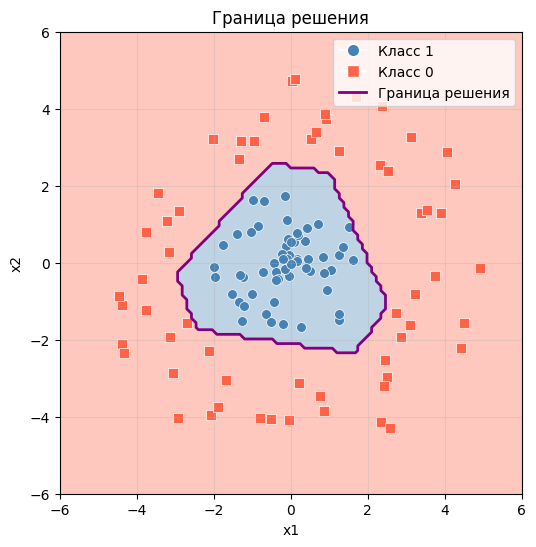

In [6]:
def predict_fn(x1, x2):
  predict = get_predict(x1, x2)
  if predict >= 0.5:
    return 1
  else:
    return 0

plot_decision_boundary(predict_fn)

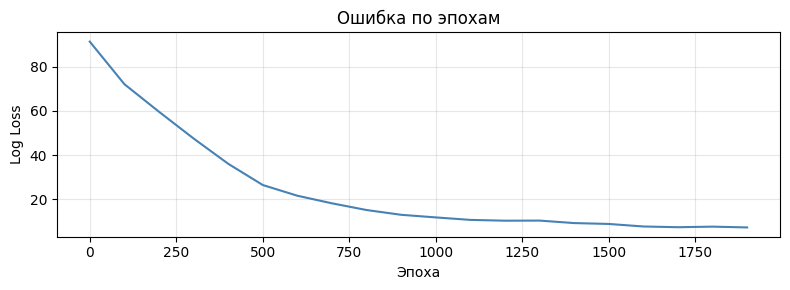

In [7]:
plt.figure(figsize=(8, 3))
plt.plot(range(0, epochs, 100), loss_history, linewidth=1.5, color='steelblue')
plt.xlabel('Эпоха')
plt.ylabel('Log Loss')
plt.title('Ошибка по эпохам')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()